Number of concepts: 37


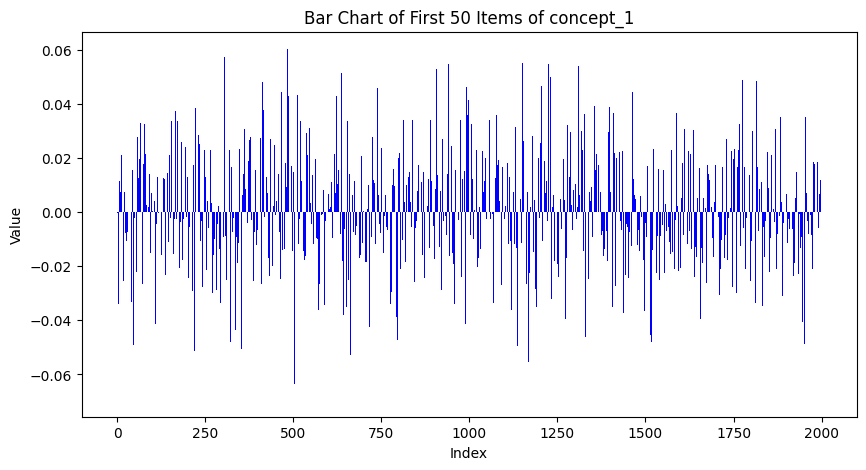

In [106]:
import torch
feature_path = "/mnt/abka03/concept_extraction_result/gemma3n/MCoX/SNMF/dtd_snmf_sparce/train/concept/redefine_activations_text_grounding_combined_concept_gl_regrounded.pth"
data = torch.load(feature_path, map_location="cpu")

hidden_states = data["concepts"]
print(f"Number of concepts: {len(hidden_states)}")
concept_1 = hidden_states[0]
import matplotlib.pyplot as plt

# Select the first 50 items of concept_1
indices = list(range(2000))
values = concept_1[:2000].numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 50 Items of concept_1")
plt.show()

In [107]:
import torch
feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet32/train/concept/redefine_activations_text_grounding_combined_concept_gl_regrounded.pth"
data = torch.load(feature_path, map_location="cpu")

hidden_states = data["concepts"]
print(f"Number of concepts: {len(hidden_states)}")
concept_1 = hidden_states[20]
import matplotlib.pyplot as plt

# Select the first 50 items of concept_1
indices = list(range(3084))
values = concept_1[:3084].numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 50 Items of concept_1")
plt.show()

Number of concepts: 27


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(v):
    return v / np.linalg.norm(v)

# Feature vectors (unit)
f_dog = normalize(np.array([2, 3]))
f_cat = normalize(np.array([-1, -2]))

# Example activation vectors
activations = [
    np.array([1.22667242, 0.87619458]),
    np.array([-1.3123357, -0.78740142]),
    np.array([1.32380284, -0.7942817]),
    np.array([-0.67514286, -1.35028572]),
]

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

for i, (ax, act) in enumerate(zip(axs, activations)):
    # Projections (scalar)
    alpha_dog = np.dot(act, f_dog)
    alpha_cat = np.dot(act, f_cat)

    print(f"Activation {i+1}: alpha_dog = {alpha_dog:.3f}, alpha_cat = {alpha_cat:.3f}")

    # Projection vectors
    proj_dog = alpha_dog * f_dog
    proj_cat = alpha_cat * f_cat
    proj_sum = proj_dog + proj_cat

    origin = np.zeros(2)

    # Plot feature vectors
    ax.quiver(*origin, *f_dog, color='blue', scale_units='xy', scale=1, width=0.007, label='Feature: Dog (unit)')
    ax.quiver(*origin, *f_cat, color='green', scale_units='xy', scale=1, width=0.007, label='Feature: Cat (unit)')

    # Plot activation vector
    ax.quiver(*origin, *act, color='red', width=0.01, scale_units='xy', scale=1, label='Activation')

    # Plot projections - positive and negative differently styled
    # Dog projection
    if alpha_dog >= 0:
        ax.quiver(*origin, *proj_dog, color='cyan', width=0.007, scale_units='xy', scale=1, label='Projection on Dog (+)')
    else:
        ax.quiver(*origin, *proj_dog, color='cyan', alpha=0.5, width=0.007, scale_units='xy', scale=1, label='Projection on Dog (-)')


    # Cat projection (start at tip of proj_dog)
    if alpha_cat >= 0:
        ax.quiver(*proj_dog, *proj_cat, color='purple', width=0.007, scale_units='xy', scale=1, label='Projection on Cat (+)')
    else:
        ax.quiver(*proj_dog, *proj_cat, color='purple', alpha=0.5, width=0.007, scale_units='xy', scale=1, label='Projection on Cat (-)')


    # Sum of projections (reconstructed vector)
    ax.quiver(*origin, *proj_sum, color='orange', width=0.007, scale_units='xy', scale=1, label='Sum of Projections')

    # Annotations
    ax.text(*(f_dog + 0.1), 'f_dog', color='blue', fontsize=10)
    ax.text(*(f_cat + 0.1), 'f_cat', color='green', fontsize=10)
    ax.text(*(act + 0.15), f'Activation {i+1}', color='red', fontsize=10)
    ax.text(*(proj_sum + 0.15), 'Reconstruction', color='orange', fontsize=10)

    # Formatting
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 4)
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Feature dimension 1')
    ax.set_ylabel('Feature dimension 2')
    ax.set_title(f'Activation Vector {i+1} Projection')

# Single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()

# Remove duplicates in legend
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, fontsize=12)

plt.suptitle('Projection of Activation Vectors onto Feature Vectors (with signed dot products)', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Activation 1: alpha_dog = 1.409, alpha_cat = -1.332
Activation 2: alpha_dog = -1.383, alpha_cat = 1.291
Activation 3: alpha_dog = 0.073, alpha_cat = 0.118
Activation 4: alpha_dog = -1.498, alpha_cat = 1.510


ValueError: At least one value in the dash list must be positive

<Figure size 1400x1200 with 4 Axes>

In [ ]:
import torch
import torch.nn.functional as F
embeddings_path = torch.load("/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/cifar100/val/features/save_hidden_states_sentence_qwen2_patched_image_apple_token_of_interest_concept_generation_split_val.pth")
embeddings = torch.stack([hid["model.language_model.norm"][0][0] for hid in embeddings_path["hidden_states"]])
print(f"Number of activations: {embeddings.shape}")  # Should be 100
feature_path = torch.load("/mnt/abka03/concept_extraction_result/publish/gemma3n/DL/SNMF/cifar100/train/concept/decompose_activations_text_grounding_image_grounding_gemma3n_results_patch_all_patch_simple.pth")
features = feature_path["concepts"]
features = features.to(dtype=torch.float32)
embeddings = embeddings.to(dtype=torch.float32)

features_norm = F.normalize(features, dim=1)      # (20, 2000)
activations_norm = F.normalize(embeddings, dim=1)  # (100, 2000)

# Compute cosine similarity: (100, 20)
similarity = torch.matmul(activations_norm, features_norm.T)

# Get indices of top-1 most similar feature vector for each activation
top_feature_indices = similarity.argmax(dim=1)  # shape: (100,)

# Select the most similar feature vector for each activation
activations = features[top_feature_indices]  # shape: (100, 2000)


Number of activations: torch.Size([50, 2048])


In [ ]:
import numpy as np

def cosine_similarity_matrix(embeddings):
    """
    Compute pairwise cosine similarity matrix for embeddings.
    embeddings: (N, d) numpy array
    returns: (N, N) similarity matrix with values in [-1, 1]
    """
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / (norms + 1e-10)  # avoid div by zero
    return normalized @ normalized.T  # cosine similarity matrix

def min_max_normalize(arr):
    """Min-max normalize a 1D array to [0,1]."""
    min_val = arr.min()
    max_val = arr.max()
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def compute_monoscore(X, embeddings):
    """
    Compute MonoSemanticity score per neuron.
    
    X: (N, omega) activations matrix
    embeddings: (N, d) embeddings from f(x)
    
    Returns:
      MS_scores: (omega,) array of monoscores for each neuron
    """
    N, omega = X.shape

    # 1. Compute pairwise similarity matrix S (N x N)
    S = cosine_similarity_matrix(embeddings)
    MS_scores = np.zeros(omega)
    for k in range(omega):
        # 2. Get activations for neuron k
        ak = X[:, k]
        # 3. Normalize activations to [0,1]
        ak_norm = min_max_normalize(ak)

        # 4. Compute relevance matrix R = ak_norm_n * ak_norm_m (outer product)
        R = np.outer(ak_norm, ak_norm)

        # 5. Exclude diagonal pairs (n == m) by zeroing them
        np.fill_diagonal(R, 0)

        # 6. Compute weighted average similarity for neuron k
        total_weight = R.sum()
        if total_weight == 0:
            MS_scores[k] = 0  # no strong activations
        else:
            MS_scores[k] = (R * S).sum() / total_weight

    return MS_scores
import numpy as np

# Assuming features_path["concepts"] exists and contains the data

# Convert both to numpy arrays
activations_np = activations.detach().cpu().numpy()
embeddings_np = embeddings.detach().cpu().numpy()

# Call your function
scores = compute_monoscore(activations_np, embeddings_np)

print( np.sort(scores)[-500:-1] )
print(scores.shape)

[0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614
 0.96019614 0.96019614 0.96019614 0.96019614 0.96019614 0.9601

In [ ]:
import torch
import torch.nn.functional as F

# Load data
embeddings_path = torch.load("/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/cifar100/val/features/combined_features.pth")
embeddings = torch.stack([hid["model.language_model.norm"][0][0] for hid in embeddings_path["hidden_states"]])

feature_dict = torch.load("//mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/imagenet1000/train/concept/redefine_activations_text_grounding_snmf_combined_concept_snmf_gl_regrounded.pth")
features = feature_dict["concepts"].to(dtype=torch.float32)[1:20]
embeddings = embeddings.to(dtype=torch.float32)
features_norm = F.normalize(features, dim=1)
activations_norm = F.normalize(embeddings, dim=1)

# Cosine similarity
similarity = torch.matmul(activations_norm, features_norm.T)  # shape: (num_activations, num_features)

# -------- Select ONLY the k-th most similar --------
k = 0  # 0-based index → e.g. k=0 is top-1, k=1 is 2nd best, etc.

# Sort similarities in descending order and get indices
sorted_similarities, sorted_indices = torch.sort(similarity, dim=1, descending=True)

# Get only the k-th most similar index
kth_indices = sorted_indices[:,k]  # shape: (num_activations,)

# Gather the k-th most similar feature vectors
kth_features = features[kth_indices]  # shape: (num_activations, feature_dim)
activations = kth_features
# ---------------------------------------------------

print(f"Selected only the {k+1}-th most similar feature per activation. Shape: {kth_features.shape}")


Selected only the 1-th most similar feature per activation. Shape: torch.Size([500, 2048])


In [ ]:
import numpy as np

def cosine_similarity_matrix(embeddings):
    """
    Compute pairwise cosine similarity matrix for embeddings.
    embeddings: (N, d) numpy array
    returns: (N, N) similarity matrix with values in [-1, 1]
    """
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / (norms + 1e-10)  # avoid div by zero
    return normalized @ normalized.T  # cosine similarity matrix

def min_max_normalize(arr):
    """Min-max normalize a 1D array to [0,1]."""
    min_val = arr.min()
    max_val = arr.max()
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def compute_monoscore(X, embeddings):
    """
    Compute MonoSemanticity score per neuron.
    
    X: (N, omega) activations matrix
    embeddings: (N, d) embeddings from f(x)
    
    Returns:
      MS_scores: (omega,) array of monoscores for each neuron
    """
    N, omega = X.shape

    # 1. Compute pairwise similarity matrix S (N x N)
    S = cosine_similarity_matrix(embeddings)
    MS_scores = np.zeros(omega)
    for k in range(omega):
        # 2. Get activations for neuron k
        ak = X[:, k]
        # 3. Normalize activations to [0,1]
        ak_norm = min_max_normalize(ak)

        # 4. Compute relevance matrix R = ak_norm_n * ak_norm_m (outer product)
        R = np.outer(ak_norm, ak_norm)

        # 5. Exclude diagonal pairs (n == m) by zeroing them
        np.fill_diagonal(R, 0)

        # 6. Compute weighted average similarity for neuron k
        total_weight = R.sum()
        if total_weight == 0:
            MS_scores[k] = 0  # no strong activations
        else:
            MS_scores[k] = (R * S).sum() / total_weight

    return MS_scores
import numpy as np

# Assuming features_path["concepts"] exists and contains the data

# Convert both to numpy arrays
activations_np = activations.detach().cpu().numpy()
embeddings_np = embeddings.detach().cpu().numpy()

# Call your function
scores = compute_monoscore(activations_np, embeddings_np)
print(f"Computed mean MonoSemanticity scores for {np.mean(scores)} neurons.")
print(f"Computed Sd MonoSemanticity scores for {np.std(scores)} neurons.")



Computed mean MonoSemanticity scores for 0.8347114469506778 neurons.
Computed Sd MonoSemanticity scores for 0.030196090080035105 neurons.


In [152]:
import torch
import torch.nn.functional as F
import numpy as np
from typing import Tuple
import random
import time

# ----------------------------- CONFIG -----------------------------
EMBEDDINGS_PATH = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/coco10/val/features/save_hidden_states_sentence_qwen2_patched_image_truck_token_of_interest_concept_generation_split_val.pth"
FEATURES_PATH = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/coco10/train/concept/redefine_activations_text_grounding_simple_combined_concept_simple_gl_regrounded.pth"

TOP_K = 0 # index, 0=top-1, 1=top-2
USE_RANDOM_SIMILARITY = False
RANDOM_SEED = 42
NORMALIZE_FEATURES = True
NORMALIZE_EMBEDDINGS = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ------------------------------------------------------------------

def load_data(
    embeddings_path: str, 
    features_path: str,
    device: str
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    emb_data = torch.load(embeddings_path, map_location=device)

    image_embeddings = torch.stack([
        hid["model.vision_tower.timm_model.msfa.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)

    # <-- add reshape here (just in case it's not [N, D]) -->
    image_embeddings = image_embeddings.reshape(image_embeddings.shape[0], -1)

    lang_embeddings = torch.stack([
        hid["model.language_model.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)

    lang_embeddings = lang_embeddings.reshape(lang_embeddings.shape[0], -1)

    feature_data = torch.load(features_path, map_location=device)
    features = feature_data["concepts"].to(dtype=torch.float32, device=device)
    # Typically features are already [num_concepts, D], but can add a .reshape if needed

    return lang_embeddings, image_embeddings, features

def get_similarity(
    lang_embeddings: torch.Tensor, 
    features: torch.Tensor,
    normalize_features: bool=True, 
    normalize_embeddings: bool=True
) -> torch.Tensor:
    if normalize_features:
        features = F.normalize(features, dim=1)
    if normalize_embeddings:
        lang_embeddings = F.normalize(lang_embeddings, dim=1)
    return torch.matmul(lang_embeddings, features.T)

def select_features(
    similarity: torch.Tensor, 
    features: torch.Tensor, 
    k: int=0, 
    use_random: bool=False, 
    seed: int=None
) -> Tuple[torch.Tensor, torch.Tensor]:
    sorted_indices = similarity.argsort(dim=1, descending=True)
    if use_random:
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
        rand_indices = torch.randint(0, sorted_indices.size(1), (sorted_indices.size(0),), device=sorted_indices.device)
        chosen_indices = sorted_indices[torch.arange(len(rand_indices)), rand_indices]
    else:
        chosen_indices = sorted_indices[:, k]
    selected_features = features[chosen_indices]
    return selected_features, chosen_indices

def cosine_similarity_matrix_torch(X: torch.Tensor) -> torch.Tensor:
    X = F.normalize(X, dim=1)
    return X @ X.T

def compute_monoscore_torch(
    activations: torch.Tensor, 
    image_embeddings: torch.Tensor, 
    threshold_percentile: float=10.
) -> torch.Tensor:
    """
    activations:  [batch_size, num_features]
    image_embeddings: [batch_size, dim]
    """
    num_features = activations.shape[1]
    # Precompute similarity matrix over embeddings (N x N)
    img_sim = cosine_similarity_matrix_torch(image_embeddings) # [N,N]
    monoscores = torch.zeros(num_features, device=activations.device)
    N = activations.shape[0]
    for k in range(num_features):
        ak = activations[:, k]
        threshold = torch.quantile(ak, threshold_percentile / 100.0)
        ak_bin = (ak >= threshold).float() # (N,)
        act_sum = ak_bin.sum().item()
        if act_sum < 2:
            monoscores[k] = 0
            continue
        R = torch.ger(ak_bin, ak_bin) # outer
        R.fill_diagonal_(0)
        total_weight = R.sum()
        monoscores[k] = (R * img_sim).sum() / total_weight if total_weight != 0 else 0
    return monoscores.cpu()

def main():
    t0 = time.time()
    lang_emb, img_emb, features = load_data(EMBEDDINGS_PATH, FEATURES_PATH, DEVICE)
    print(f"Loaded lang_emb {lang_emb.shape} | img_emb {img_emb.shape} | features {features.shape}")
    similarity = get_similarity(
        lang_emb, features,
        normalize_features=NORMALIZE_FEATURES,
        normalize_embeddings=NORMALIZE_EMBEDDINGS
    )
    selected_features, indices = select_features(
        similarity, features,
        k=TOP_K, use_random=USE_RANDOM_SIMILARITY, seed=RANDOM_SEED
    )
    print(f"Selected {'random' if USE_RANDOM_SIMILARITY else f'top-{TOP_K + 1}'} feature per example. Shape: {selected_features.shape}")

    # If you want more features (all of them), use a slice, otherwise stick with current
    # (N, feature_dim): selected_features

    # activations: each row = sample's selected "concept" neuron activations
    monoscores = compute_monoscore_torch(selected_features, img_emb)
    t1 = time.time()

    print("\n--- MonoSemanticity Score ---")
    print(f"Mean Score: {monoscores.mean().item():.4f}")
    print(f"Std Dev  : {monoscores.std().item():.4f}")
    print(f"Finished in {t1 - t0:.1f} seconds")

if __name__ == "__main__":
    main()

Loaded lang_emb torch.Size([50, 2048]) | img_emb torch.Size([50, 256]) | features torch.Size([10, 2048])
Selected top-1 feature per example. Shape: torch.Size([50, 2048])

--- MonoSemanticity Score ---
Mean Score: 0.5975
Std Dev  : 0.0043
Finished in 0.5 seconds


In [166]:

import torch
import torch.nn.functional as F
import numpy as np
import os
import itertools

from typing import Tuple, List

# ========== USER CONFIG =============
EMBEDDINGS_ROOT = "/mnt/abka03/concept_extraction_result/publish/gemma3n/DL/SNMF/coco10/val/features"
FEATURES_ROOT = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/coco10/train/concept"
TOP_K = 0
USE_RANDOM_SIMILARITY = False
RANDOM_SEED = 42
NORMALIZE_FEATURES = True
NORMALIZE_EMBEDDINGS = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Files to use (edit the paths if files are in subdirs)
FEATURE_FILENAMES = [
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_pca.pth",
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_sae2.pth",
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_simple.pth",
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_snmf.pth"
]
EMBEDDING_FILENAMES = [
    "save_hidden_states_for_token_of_interest_qwen2_patched_image_airplane_token_of_interest_concept_generation_split_val.pth",
    "save_hidden_states_for_token_of_interest_qwen2_patched_image_car_token_of_interest_concept_generation_split_val.pth",
]
# ====================================

def get_selected_files(root: str, wanted_names: List[str]) -> List[str]:
    return [
        os.path.join(root, fname)
        for fname in wanted_names if os.path.isfile(os.path.join(root, fname))
    ]

def load_data(embeddings_path: str, features_path: str, device: str):
    emb_data = torch.load(embeddings_path, map_location=device)
    image_embeddings = torch.stack([
        hid["model.vision_tower.timm_model.msfa.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)
    image_embeddings = image_embeddings.reshape(image_embeddings.shape[0], -1)
    lang_embeddings = torch.stack([
        hid["model.language_model.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)
    lang_embeddings = lang_embeddings.reshape(lang_embeddings.shape[0], -1)
    feature_data = torch.load(features_path, map_location=device)
    features = feature_data["concepts"].to(dtype=torch.float32, device=device)
    return lang_embeddings, image_embeddings, features

def get_similarity(lang_embeddings, features, normalize_features=True, normalize_embeddings=True):
    if normalize_features:
        features = F.normalize(features, dim=1)
    if normalize_embeddings:
        lang_embeddings = F.normalize(lang_embeddings, dim=1)
    return torch.matmul(lang_embeddings, features.T)

def select_features(similarity, features, k=0, use_random=False, seed=None):
    sorted_indices = similarity.argsort(dim=1, descending=True)
    if use_random:
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
        rand_indices = torch.randint(0, sorted_indices.size(1), (sorted_indices.size(0),), device=sorted_indices.device)
        chosen_indices = sorted_indices[torch.arange(len(rand_indices)), rand_indices]
    else:
        chosen_indices = sorted_indices[:, k]
    selected_features = features[chosen_indices]
    return selected_features, chosen_indices

def cosine_similarity_matrix_torch(X: torch.Tensor) -> torch.Tensor:
    X = F.normalize(X, dim=1)
    return X @ X.T

def compute_monoscore_torch(activations, image_embeddings, threshold_percentile=100.):
    num_features = activations.shape[1]
    img_sim = cosine_similarity_matrix_torch(image_embeddings)
    monoscores = torch.zeros(num_features, device=activations.device)
    for k in range(num_features):
        ak = activations[:, k]
        threshold = torch.quantile(ak, threshold_percentile / 100.0)
        ak_bin = (ak >= threshold).float()
        act_sum = ak_bin.sum().item()
        if act_sum < 2:
            monoscores[k] = 0
            continue
        R = torch.ger(ak_bin, ak_bin)
        R.fill_diagonal_(0)
        total_weight = R.sum()
        monoscores[k] = (R * img_sim).sum() / total_weight if total_weight != 0 else 0
    return monoscores.cpu()

def process_pair(emb_path, feat_path):
    try:
        lang_embeddings, image_embeddings, features = load_data(emb_path, feat_path, DEVICE)
        similarity = get_similarity(
            lang_embeddings, features,
            normalize_features=NORMALIZE_FEATURES,
            normalize_embeddings=NORMALIZE_EMBEDDINGS
        )
        selected_features, indices = select_features(
            similarity, features,
            k=TOP_K, use_random=USE_RANDOM_SIMILARITY, seed=RANDOM_SEED
        )
        monoscores = compute_monoscore_torch(selected_features, image_embeddings)
        mean_score, std_score = monoscores.mean().item(), monoscores.std().item()
        return mean_score, std_score
    except Exception as e:
        print(f"Error processing [{emb_path}] and [{feat_path}]: {e}")
        return None, None

def main():
    emb_files = get_selected_files(EMBEDDINGS_ROOT, EMBEDDING_FILENAMES)
    feature_files = get_selected_files(FEATURES_ROOT, FEATURE_FILENAMES)
    print(f"Using {len(emb_files)} embedding files and {len(feature_files)} feature files.")

    pairs = list(itertools.product(emb_files, feature_files))
    results = []
    for emb_path, feat_path in pairs:
        print(f"\nProcessing:\n  Embedding: {os.path.basename(emb_path)}\n  Feature:   {os.path.basename(feat_path)}")
        mean_score, std_score = process_pair(emb_path, feat_path)
        print(f"  --> mean monoscore: {mean_score}, std: {std_score}")
        results.append({
            'embedding_file': os.path.basename(emb_path),
            'feature_file': os.path.basename(feat_path),
            'mean': mean_score,
            'std': std_score,
        })

    print("\n\n======= SUMMARY TABLE =======")
    print("{:55} {:55} {:10} {:10}".format("Embedding File", "Feature File", "mean", "std"))
    for row in results:
        print("{:55} {:55} {:<10.4f} {:<10.4f}".format(
            row['embedding_file'], 
            row['feature_file'],
            row['mean'] if row['mean'] is not None else float("nan"),
            row['std'] if row['std'] is not None else float("nan")
        ))

if __name__ == "__main__":
    main()

Using 2 embedding files and 0 feature files.


======= SUMMARY TABLE =======
Embedding File                                          Feature File                                            mean       std       
